# [PDF Loader](https://python.langchain.com/docs/integrations/document_loaders/#pdfs)

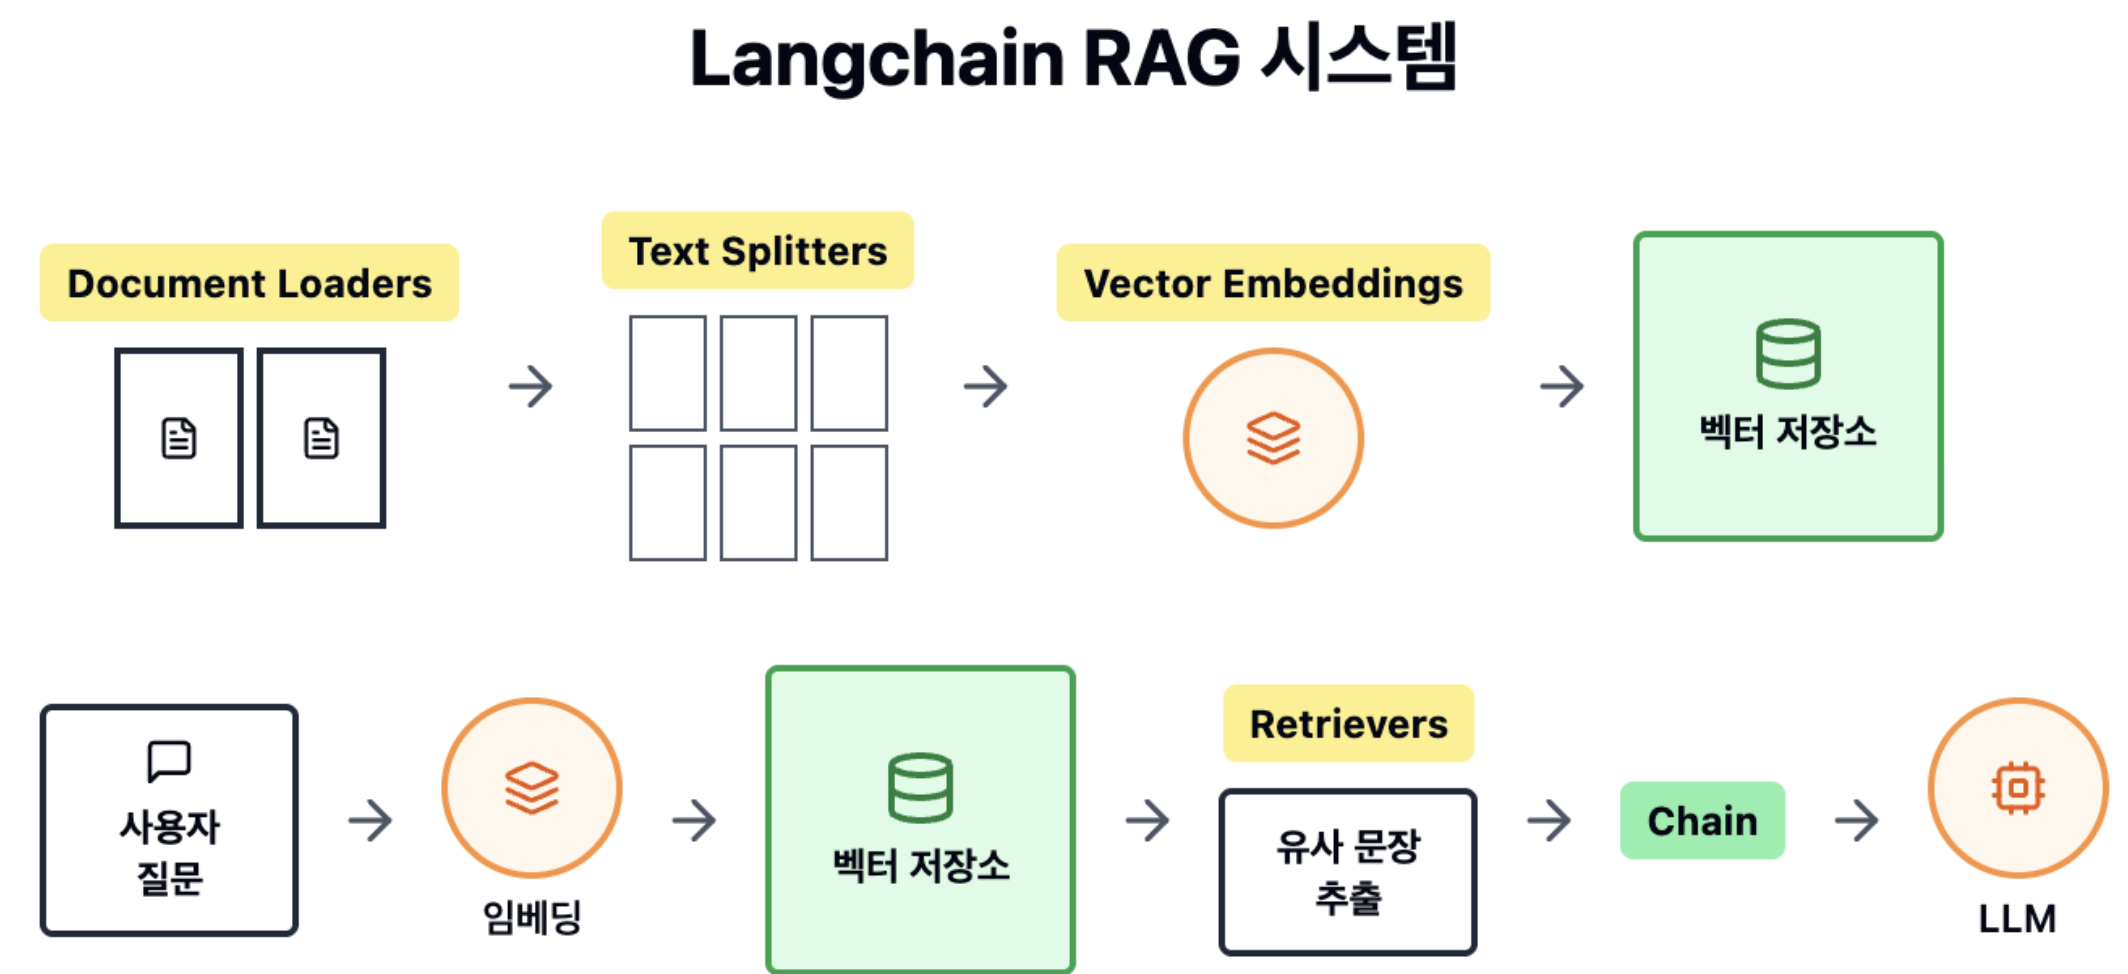

## PDF Loader가 중요한 이유
- RAG에서 PDF는 가장 흔한 데이터 소스 중 하나이며, PDF의 `텍스트 레이아웃`, `표 구조`, `이미지 포함 여부`에 따라 정확한 자료 추출 품질이 크게 달라진다.
- 따라서 문서 형태에 맞는 로더 선택은 `RAG 전체 품질을 좌우하는 핵심 요소`다.

## PDF Loader 3종 핵심 비교

### PyPDFLoader
- 가장 기본적인 텍스트 중심 PDF 로더
- 가볍고 빠르지만 기능 제한
- 단순 텍스트 문서에 적합


### PDFPlumberLoader
- 표(Table)와 레이아웃 분석에 최적화된 로더
- 테이블 추출 정확도 최고
- 형식이 있는 보고서나 논문에 강함

### PyMuPDF4LLMLoader
- 이미지·텍스트·구조를 가장 유연하게 처리하는 최신 로더
- 텍스트 + 이미지 + 구조까지 모두 지원
- PDF 내부 이미지(Blob) 완전 추출

## 상황별 로더 선택 가이드
| 상황            | 적합한 로더                |
| ------------- | --------------------- |
| 텍스트 기반 단순 PDF | **PyPDFLoader**       |
| 표 구조 중심 PDF   | **PDFPlumberLoader**  |
| 이미지·스캔 포함 PDF | **PyMuPDF4LLMLoader** |
| 가장 범용적인 로더    | **PyMuPDF4LLMLoader** |


## 추가 추천 PDF Loaders (LangChain 통합 대상)

| 로더 이름                          | 특징 및 장점 / 언제 쓰면 좋은가                                                                                                                                                         |
| ------------------------------ | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **UnstructuredPDFLoader**      | “텍스트 + 레이아웃 + 구조(단락, 리스트, 표 등)”를 좀 더 일반적인 방식으로 파싱해주는 로더. 단순 텍스트 추출보다는 구조를 살리고 싶을 때 유용. 복잡한 레이아웃의 PDF, 마크다운/HTML-like 출력이 필요한 경우 사용 추천. ([LangChain][1])                     |
| **PyPDFium2Loader**            | 백엔드로 `PyPDFium2` (PDFium) 라이브러리를 사용하는 로더. PDF를 렌더링 기반으로 처리하기 때문에, 렌더링된 페이지 이미지 기반 OCR 처리나 이미지 포함 PDF 처리 + 후처리에 유리. “텍스트 레이어가 불완전하거나 이미지 + 텍스트 혼합 PDF”에 유용. ([LangChain][1]) |
| **PDFMinerLoader**             | 전통적인 PDF 텍스트 추출 라이브러리인 `PDFMiner` 기반. 텍스트만 있는 PDF에서 최대한 원본의 텍스트 레이어를 파싱하고 싶을 때 적합. 레이아웃 단순한 리포트나 논문 같은 문서에 유리. ([LangChain][1])                                             |
| **MathPixPDFLoader**           | 수식(LaTeX, 이미지 내 수식 포함) PDF를 처리할 때 유용한 로더. 일반 PDF 로더가 수식이나 이미지 내 수식을 잘 처리하지 못할 경우, MathPix를 활용하면 수식 OCR/파싱이 가능 — 과학 논문, 수학 문서에 특히 적합. ([LangChain][1])                       |
| **Amazon Textract PDF Loader** | AWS 기반의 PDF 파싱 API를 사용하는 로더. 특히 스캔된 PDF, 이미지 기반 PDF, 구조가 복잡한 보고서 등에서 강함. 클라우드 API를 활용하므로 로컬 처리에 부담이 있을 때 — 또는 대량 PDF 처리가 필요할 때 유용. ([LangChain][1])                         |

[1]: https://python.langchain.com/docs/integrations/document_loaders/?utm_source=chatgpt.com "Document loaders | 🦜️🔗 LangChain"


# 예제

## PDF 파일들

In [1]:
pdf_attention = "data/Attention Is All You Need.pdf"
pdf_bert = "data/BERT.pdf"
pdf_lg_aimers = "data/LG Aimers 4기 소개자료.pdf"

## [PDFPlumberLoader](https://python.langchain.com/docs/integrations/document_loaders/pdfplumber/)

### PyPDFLoader vs PDFPlumberLoader

| 특징 | PyPDFLoader | PDFPlumberLoader |
|------|-------------|------------------|
| **속도** | 빠름 | 상대적으로 느림 |
| **정확도** | 보통 | 높음 (표, 레이아웃 정확) |
| **표 추출** | 어려움 | 우수 |
| **레이아웃 보존** | 어려움 | 우수 |
| **복잡한 PDF** | 제한적 | 잘 처리함 |
| **사용 권장** | 단순한 PDF | 표/레이아웃이 중요한 PDF |

### 예제: PDFPlumberLoader

##### PDFPlumberLoader 파라미터 설명

| 파라미터 | 필수 여부 | 설명 | 예시 |
|---------|---------|------|------|
| `file_path` | 필수 | PDF 파일 경로 (로컬 파일 경로만 지원) | `"./document.pdf"` |
| `text_kwargs` | 선택 | pdfplumber의 extract_text() 메서드에 전달할 옵션 | `{"layout": True, "x_tolerance": 3}` |
| `extract_images` | 선택 | 이미지 추출 여부 (기본값: False) | `True` 또는 `False` |

> text_kwargs 주요 옵션

| 옵션 | 설명 | 기본값 |
|------|------|--------|
| `layout` | 원본 레이아웃 유지 (공백, 줄바꿈 보존) | `False` |
| `x_tolerance` | 같은 줄로 인식할 가로 간격 허용 오차 (픽셀) | `3` |
| `y_tolerance` | 같은 줄로 인식할 세로 간격 허용 오차 (픽셀) | `3` |
| `x_density` | 텍스트 추출 가로 해상도 | `7.25` |
| `y_density` | 텍스트 추출 세로 해상도 | `7.25` |

In [2]:
from langchain_community.document_loaders import PDFPlumberLoader

loader = PDFPlumberLoader(pdf_lg_aimers)

In [3]:
docs = loader.load()
print(f"PDF 파일의 페이지 수: {len(docs)}")

PDF 파일의 페이지 수: 7


#### 메타정보 추출 

In [4]:
docs[1].metadata

{'source': 'data/LG Aimers 4기 소개자료.pdf',
 'file_path': 'data/LG Aimers 4기 소개자료.pdf',
 'page': 1,
 'total_pages': 7,
 'CreationDate': "D:20250715074032+00'00'",
 'ModDate': "D:20250715074032+00'00'"}

#### 텍스트 추출

In [5]:
print(docs[1].page_content[:300])

1. LG Aimers 프로그램 개요
❑교육과 경험의 기회를 필요로 하는 청년들에게 양질의 AI교육을 온라인으로 제공하고, 기업의 실제 data를 다루며
실무를 경험할 수 있는 기회를 제공하기 위해 『온라인 AI전문가 과정(1개월)』 과 『AI 해커톤 (Hackathon)(1개월)』을
결합한 형태의 교육 프로그램
- 온라인 AI 교육 과정 : 국내 AI 전문가 (현업 전문가, 저명 교수)의 최신 AI 기법에 관한 온라인 강의(1개월)
• 온라인 초급 교육은 기초적인 프로그래밍데이터 처리에 관련된 내용들로써 외부 교육 콘텐츠를 활용(


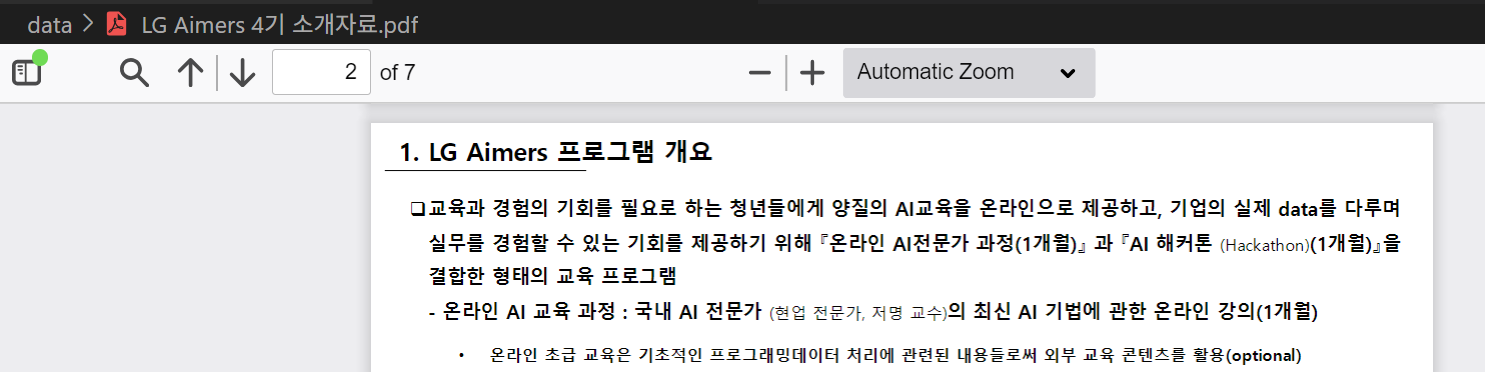

### [예제: pdfplumber](https://github.com/jsvine/pdfplumber)

#### 메타정보 추출

In [6]:
import pdfplumber

with pdfplumber.open(pdf_bert) as pdf:
    metadata = pdf.metadata
    print(metadata)

{'Author': '', 'CreationDate': 'D:20190528000751Z', 'Creator': 'LaTeX with hyperref package', 'Keywords': '', 'ModDate': 'D:20190528000751Z', 'PTEX.Fullbanner': 'This is pdfTeX, Version 3.14159265-2.6-1.40.17 (TeX Live 2016) kpathsea version 6.2.2', 'Producer': 'pdfTeX-1.40.17', 'Subject': '', 'Title': '', 'Trapped': 'False'}


#### 텍스트 추출

In [7]:
with pdfplumber.open(pdf_bert) as pdf:
    text = pdf.pages[0].extract_text()
    print(text[:300])

BERT: Pre-training of Deep Bidirectional Transformers for
Language Understanding
JacobDevlin Ming-WeiChang KentonLee KristinaToutanova
GoogleAILanguage
{jacobdevlin,mingweichang,kentonl,kristout}@google.com
Abstract There are two existing strategies for apply-
ingpre-trainedlanguage representations 


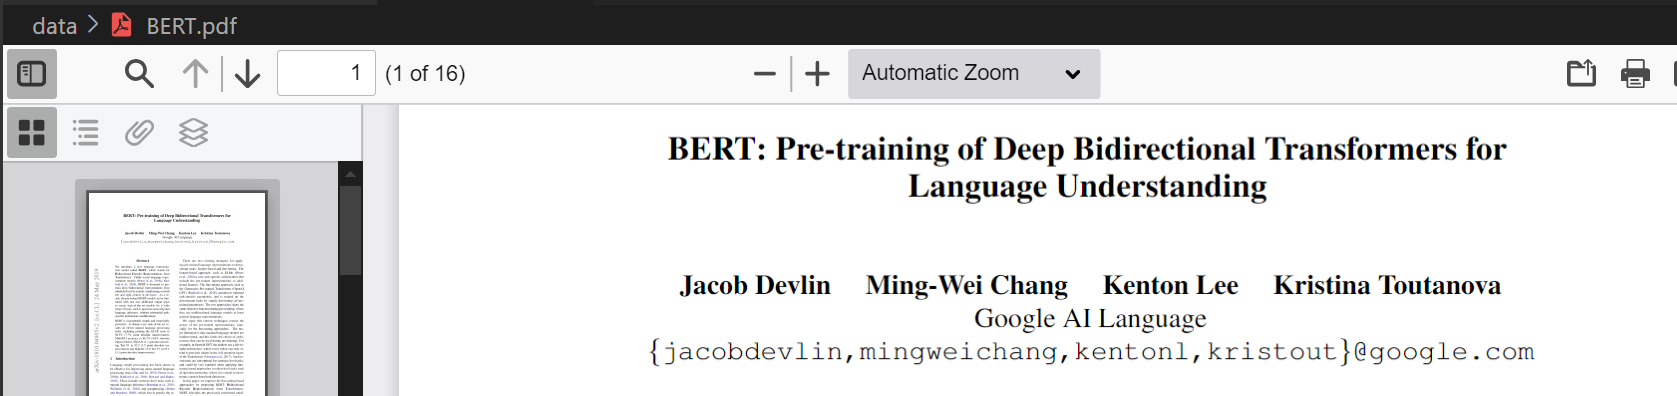

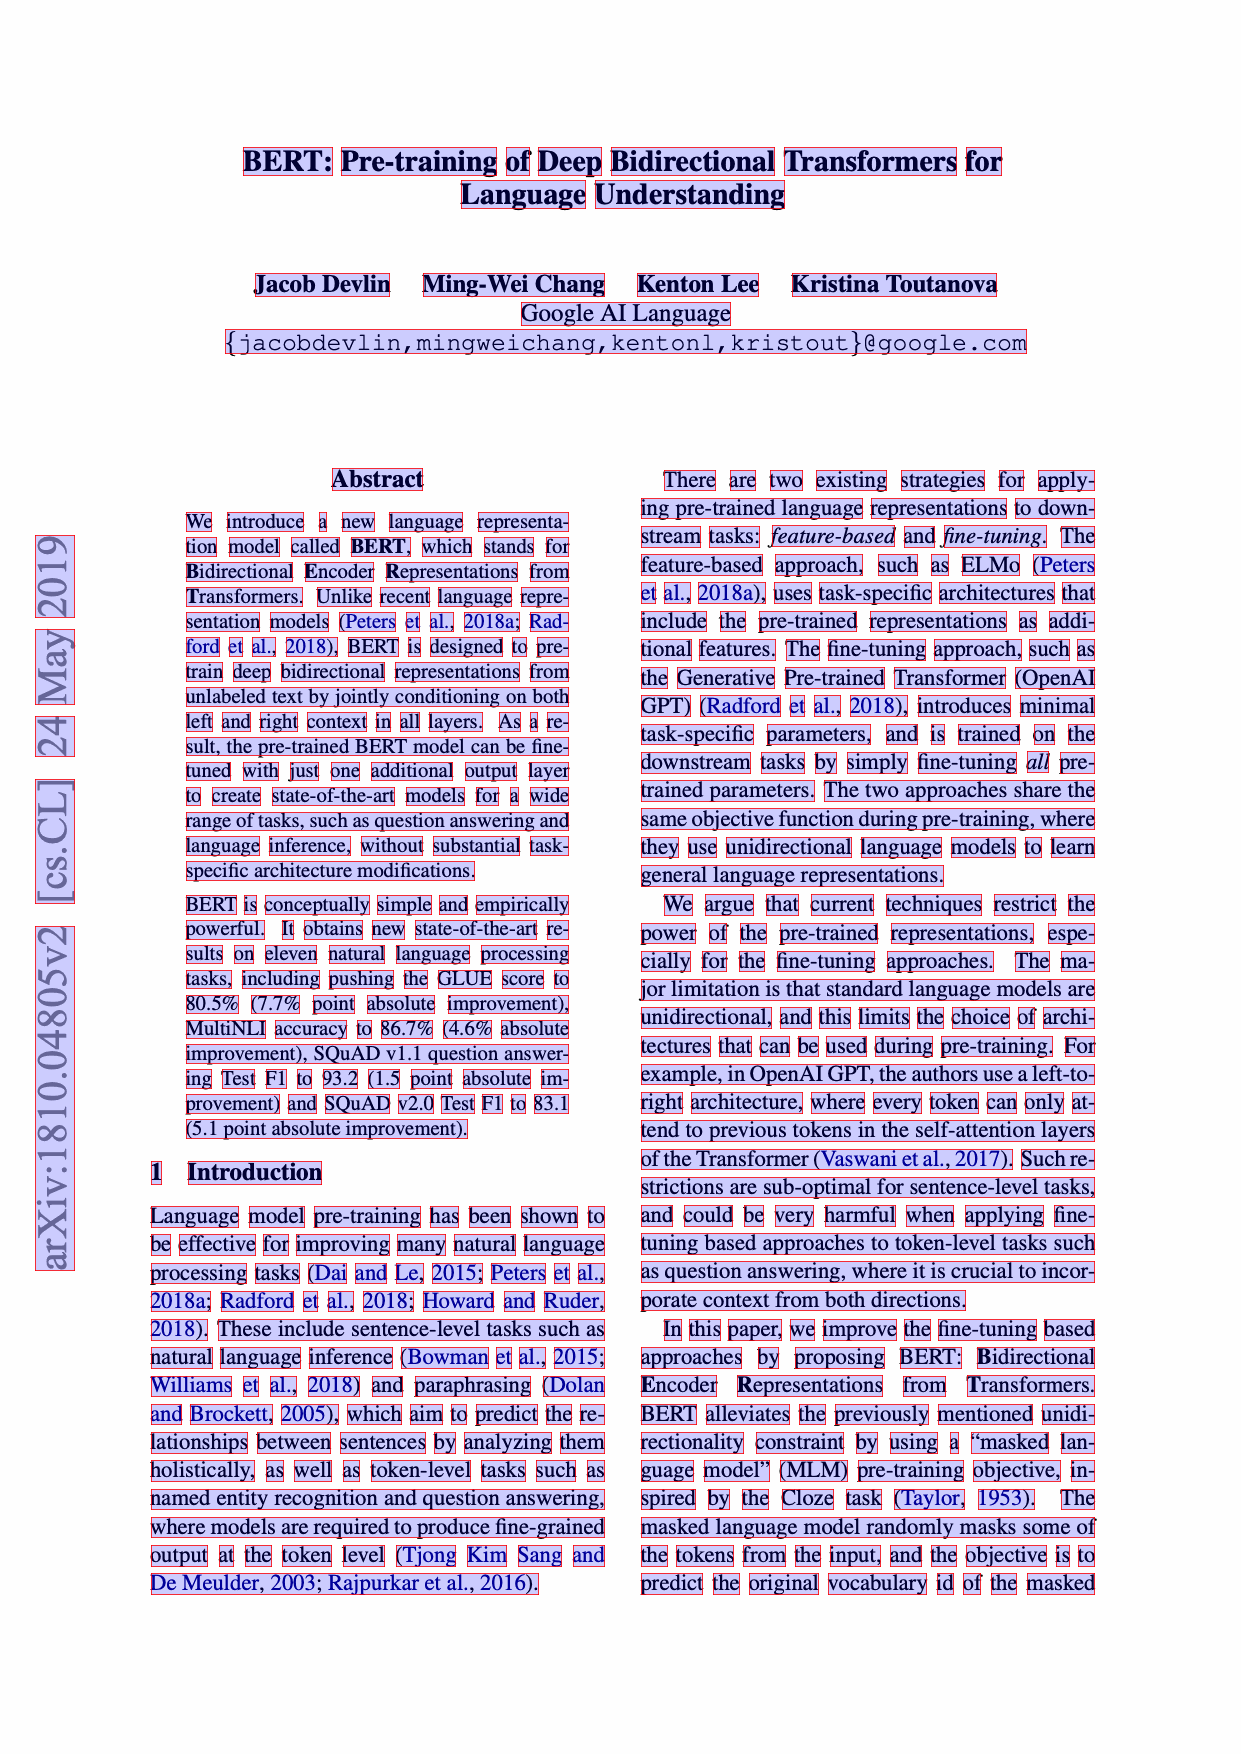

In [8]:
with pdfplumber.open(pdf_bert) as pdf:
    pages = pdf.pages
    im = pages[0].to_image(resolution=150)
    im.draw_rects(pages[0].extract_words())

im

#### with Langchain Document

In [9]:
import pdfplumber
from langchain_core.documents import Document

# Open the PDF file"
documents = []

with pdfplumber.open(pdf_bert) as pdf:
    dict_metadata = pdf.metadata

    # Iterate through all the pages in the PDF document
    for i, page in enumerate(pdf.pages):
        # Extract and print the text content of each page
        dict_metadata['page_no'] = i+1
        documents.append(Document(
            page_content=page.extract_text(),
            metadata=dict_metadata
        ))

> 추출된 메타데이터 확인 

In [10]:
documents[0].metadata

{'Author': '',
 'CreationDate': 'D:20190528000751Z',
 'Creator': 'LaTeX with hyperref package',
 'Keywords': '',
 'ModDate': 'D:20190528000751Z',
 'PTEX.Fullbanner': 'This is pdfTeX, Version 3.14159265-2.6-1.40.17 (TeX Live 2016) kpathsea version 6.2.2',
 'Producer': 'pdfTeX-1.40.17',
 'Subject': '',
 'Title': '',
 'Trapped': 'False',
 'page_no': 1}

> 추출된 텍스트 확인 

In [11]:
print(documents[0].page_content[:300])

BERT: Pre-training of Deep Bidirectional Transformers for
Language Understanding
JacobDevlin Ming-WeiChang KentonLee KristinaToutanova
GoogleAILanguage
{jacobdevlin,mingweichang,kentonl,kristout}@google.com
Abstract There are two existing strategies for apply-
ingpre-trainedlanguage representations 


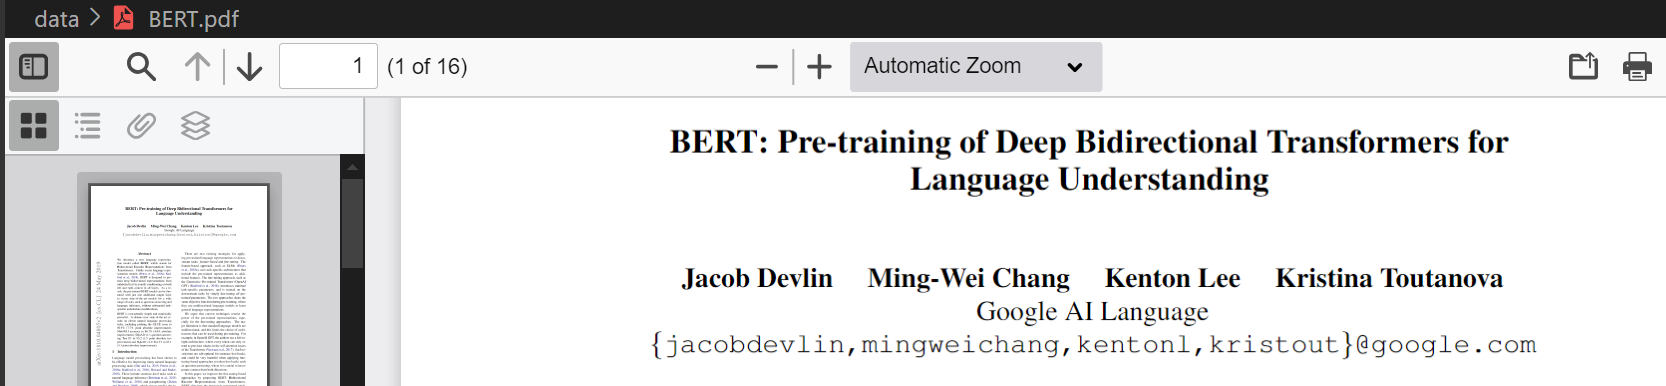